# OASIS Alzheimer's Classification — Baseline Model Pipeline

**Goal:** Train and compare a broad panel of classifiers — three baselines (Logistic Regression, Random Forest, XGBoost), seven additional models, and one heterogeneous stacking ensemble — on the preprocessed OASIS cross-sectional data to classify subjects as **Demented vs. Nondemented**.

**Methodological note on `CDR`:** `CDR` (Clinical Dementia Rating) is the exact variable used to derive the `Group`/target label (CDR = 0 → Nondemented, CDR > 0 → Demented). It is therefore **excluded from the feature set** to avoid label leakage. All models below are trained on the biomarker/demographic feature set only: `Age`, `Gender`, `Educ`, `SES`, `MMSE`, `eTIV`, `nWBV`, `ASF`.

In [3]:
import sys
!{sys.executable} -m pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 3.4/100.2 MB 15.8 MB/s eta 0:00:07
   --- ------------------------------------ 7.6/100.2 MB 17.6 MB/s eta 0:00:06
   ---- ----------------------------------- 11.5/100.2 MB 17.5 MB/s eta 0:00:06
   ----- ---------------------------------- 14.7/100.2 MB 17.0 MB/s eta 0:00:06
   ------- -------------------------------- 18.6/100.2 MB 17.0 MB/s eta 0:00:05
   --------- ------------------------------ 22.8/100.2 MB 17.4 MB/s eta 0:00:05
   ---------- ----------------------------- 27.3/100.2 MB 17.8 MB/s eta 0:00:05
   ------------ --------------------------- 31.5/100.2 MB 18.0 MB/s eta 0:00:04
   -------------- ------------------------- 35.4/100.2 MB 18.1 MB/s eta 0:00:04
   --------------- ------------------------ 39.8/100.2 MB 18.3

In [4]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, average_precision_score,
    brier_score_loss, log_loss, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42

## 1. Load and Prepare Data

In [5]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)
df = df[df["Group"] != "Unknown"].reset_index(drop=True)  # drop subjects with no diagnosis

# Impute the few legitimately missing clinical fields (median)
for col in ["Educ", "SES", "MMSE"]:
    df[col] = df[col].fillna(df[col].median())

# Encode
df["Gender"] = df["M/F"].map({"M": 0, "F": 1})
df["Target"] = df["Group"].map({"Nondemented": 0, "Demented": 1})

# Feature set: biomarkers/demographics only -- CDR is excluded (see leakage note above)
FEATURES = ["Age", "Gender", "Educ", "SES", "MMSE", "eTIV", "nWBV", "ASF"]

X = df[FEATURES]
y = df["Target"]

print(f"Dataset shape after cleaning: {df.shape}")
print(y.value_counts())
df.head()

Dataset shape after cleaning: (235, 15)
Target
0    135
1    100
Name: count, dtype: int64


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Group,Gender,Target
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,Nondemented,1,0
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,Nondemented,1,0
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,Demented,1,1
3,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN,Nondemented,0,0
4,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329,NaN,Nondemented,1,0


## 2. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (188, 8), Test: (47, 8)


## 3. Train Baseline Models

In [7]:
baseline_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
}

## 4. Evaluation

Shared helper functions used to score every model in this notebook (baselines, remaining models, and the hybrid ensemble) on a single, consistent metric suite covering both discrimination (Table 1A) and calibration/cost (Table 1B).

In [8]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    '''Bin predicted probabilities into n_bins and average the |accuracy - confidence| gap.'''
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    n = len(y_true)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])
        ece += (mask.sum() / n) * abs(acc - conf)
    return ece


def calibration_slope(y_true, y_prob):
    '''Slope of a logistic regression of y_true on logit(y_prob); 1.0 = perfectly calibrated.'''
    eps = 1e-6
    p = np.clip(y_prob, eps, 1 - eps)
    logit = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LogisticRegression()
    lr.fit(logit, y_true)
    return float(lr.coef_[0][0])


def count_params(model):
    '''Best-effort count of a fitted model's learned parameters, used as a rough
    complexity proxy in Table 1B (coefficients, tree nodes, support vectors, etc.).'''
    try:
        if isinstance(model, StackingClassifier):
            total = sum(count_params(est) for est in model.estimators_)
            total += count_params(model.final_estimator_)
            return int(total)
        if isinstance(model, LogisticRegression):
            return int(model.coef_.size + model.intercept_.size)
        if isinstance(model, SVC):
            if model.kernel == "linear":
                return int(model.coef_.size + model.intercept_.size)
            return int(model.support_vectors_.size + model.dual_coef_.size + model.intercept_.size)
        if isinstance(model, (RandomForestClassifier, ExtraTreesClassifier)):
            return int(sum(est.tree_.node_count for est in model.estimators_))
        if isinstance(model, DecisionTreeClassifier):
            return int(model.tree_.node_count)
        if isinstance(model, MLPClassifier):
            return int(sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_))
        if hasattr(model, "get_booster"):        # XGBoost
            return int(model.get_booster().trees_to_dataframe().shape[0])
        if hasattr(model, "booster_"):            # LightGBM
            return int(model.booster_.num_trees())
        if hasattr(model, "tree_count_"):         # CatBoost
            return int(model.tree_count_)
    except Exception:
        return np.nan
    return np.nan


# Running stores populated by every "train + evaluate" step below
table1a_rows = []
table1b_rows = []
fitted_models = {}
y_preds = {}
y_probas = {}


def train_and_evaluate(name, model, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test):
    '''Fit `model`, score it on the held-out test set, and append its row to
    Table 1A / Table 1B. Returns the fitted model.'''
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    inference_time = time.time() - t0

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    table1a_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Bal. Accuracy": balanced_accuracy_score(y_te, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "NPV": npv,
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_te, y_pred),
        "AUROC": roc_auc_score(y_te, y_proba),
        "AUPRC": average_precision_score(y_te, y_proba),
    })
    table1b_rows.append({
        "Model": name,
        "Brier": brier_score_loss(y_te, y_proba),
        "Log Loss": log_loss(y_te, y_proba),
        "ECE": expected_calibration_error(y_te.values, y_proba),
        "Calibration Slope": calibration_slope(y_te.values, y_proba),
        "Parameters": count_params(model),
        "Training Time": train_time,
        "Inference Time": inference_time,
    })

    fitted_models[name] = model
    y_preds[name] = y_pred
    y_probas[name] = y_proba
    return model


for name, model in baseline_models.items():
    train_and_evaluate(name, model)

print("Baseline models trained:", list(baseline_models.keys()))

Baseline models trained: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 5. Remaining Models

Linear SVM, RBF SVM, Decision Tree, Extra Trees, LightGBM, CatBoost, and MLP -- trained and scored with the same `train_and_evaluate` pipeline as the baselines.

In [9]:
remaining_models = {
    "Linear SVM": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
    "RBF SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=200),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    "MLP": MLPClassifier(random_state=RANDOM_STATE, max_iter=1000),
}

for name, model in remaining_models.items():
    train_and_evaluate(name, model)

print("Remaining models trained:", list(remaining_models.keys()))

Remaining models trained: ['Linear SVM', 'RBF SVM', 'Decision Tree', 'Extra Trees', 'LightGBM', 'CatBoost', 'MLP']


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## 6. Hybrid Ensemble

One heterogeneous stacking ensemble: Random Forest, Extra Trees, CatBoost, and XGBoost as base learners, with a Logistic Regression meta-learner combining their out-of-fold predictions.

```
Random Forest
Extra Trees          →   Logistic Regression
CatBoost
XGBoost
```

In [10]:
hybrid_ensemble = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)),
        ("et", ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=200)),
        ("cat", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)),
        ("xgb", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

train_and_evaluate("Hybrid Ensemble", hybrid_ensemble)
print("Hybrid Ensemble trained.")

Hybrid Ensemble trained.


## 7. Table 1A — Discrimination Metrics

In [11]:
table1a = pd.DataFrame(table1a_rows).set_index("Model").round(3)
table1a = table1a.sort_values("AUROC", ascending=False)
table1a

,Accuracy,Bal. Accuracy,Sensitivity,Specificity,Precision,NPV,F1,MCC,AUROC,AUPRC
Model,,,,,,,,,,
Random Forest,0.830,0.813,0.70,0.926,0.875,0.806,0.778,0.653,0.942,0.931
XGBoost,0.851,0.838,0.75,0.926,0.882,0.833,0.811,0.696,0.941,0.931
Hybrid Ensemble,0.830,0.813,0.70,0.926,0.875,0.806,0.778,0.653,0.933,0.922
CatBoost,0.809,0.794,0.70,0.889,0.824,0.800,0.757,0.606,0.926,0.911
LightGBM,0.809,0.801,0.75,0.852,0.789,0.821,0.769,0.606,0.919,0.910
RBF SVM,0.787,0.782,0.75,0.815,0.750,0.815,0.750,0.565,0.913,0.908
Extra Trees,0.787,0.776,0.70,0.852,0.778,0.793,0.737,0.561,0.909,0.902
Logistic Regression,0.787,0.776,0.70,0.852,0.778,0.793,0.737,0.561,0.906,0.897
MLP,0.851,0.851,0.85,0.852,0.810,0.885,0.829,0.698,0.902,0.893


## 8. Table 1B — Calibration, Complexity & Timing

In [12]:
table1b = pd.DataFrame(table1b_rows).set_index("Model").round(4)
table1b = table1b.loc[table1a.index]  # keep same model ordering as Table 1A
table1b

,Brier,Log Loss,ECE,Calibration Slope,Parameters,Training Time,Inference Time
Model,,,,,,,
Random Forest,0.1037,0.3350,0.1173,1.4003,12928,0.8417,0.0702
XGBoost,0.1163,0.3530,0.1164,0.5966,1186,0.3921,0.0097
Hybrid Ensemble,0.1186,0.3744,0.1394,1.1857,50403,24.0162,0.1563
CatBoost,0.1207,0.3488,0.1255,0.8808,1000,2.7323,0.0056
LightGBM,0.1241,0.3761,0.1218,0.6552,100,3.1375,0.0064
RBF SVM,0.1195,0.3868,0.1434,1.3367,1027,0.0139,0.0048
Extra Trees,0.1211,0.3783,0.0967,1.2624,35284,0.3977,0.0594
Logistic Regression,0.1271,0.3763,0.1063,0.8187,9,0.0538,0.0066
MLP,0.1554,0.5751,0.1843,0.3228,1001,1.3689,0.0045


## 9. Calibration Curves

Reliability diagrams for XGBoost, the Hybrid Ensemble, and CatBoost.

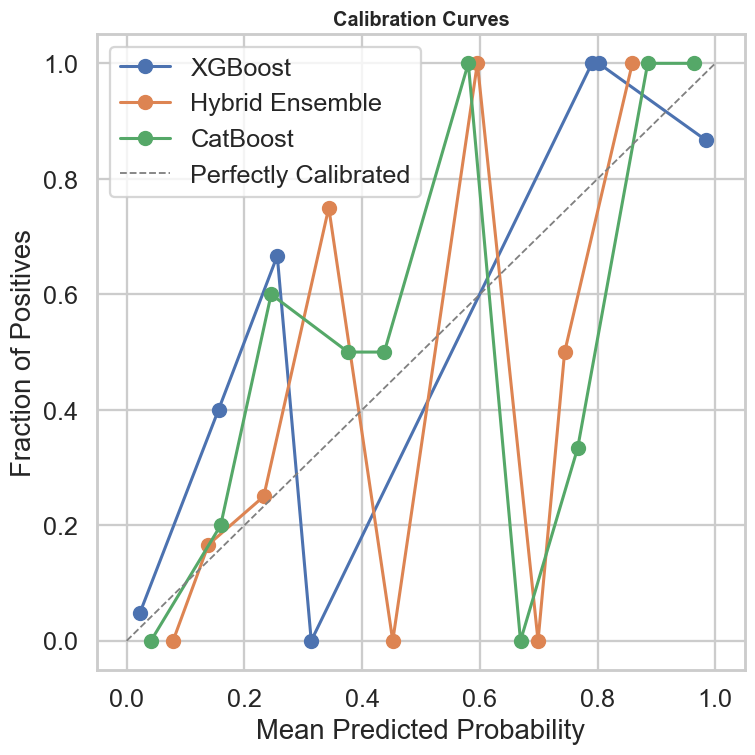

In [13]:
calib_models = ["XGBoost", "Hybrid Ensemble", "CatBoost"]

fig, ax = plt.subplots(figsize=(7, 7))
for name in calib_models:
    frac_pos, mean_pred = calibration_curve(y_test, y_probas[name], n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Perfectly Calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curves")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 10. ROC Curves — Top 3 Models

Ranked by AUROC (Table 1A).

Top 3 models by AUROC: ['Random Forest', 'XGBoost', 'Hybrid Ensemble']


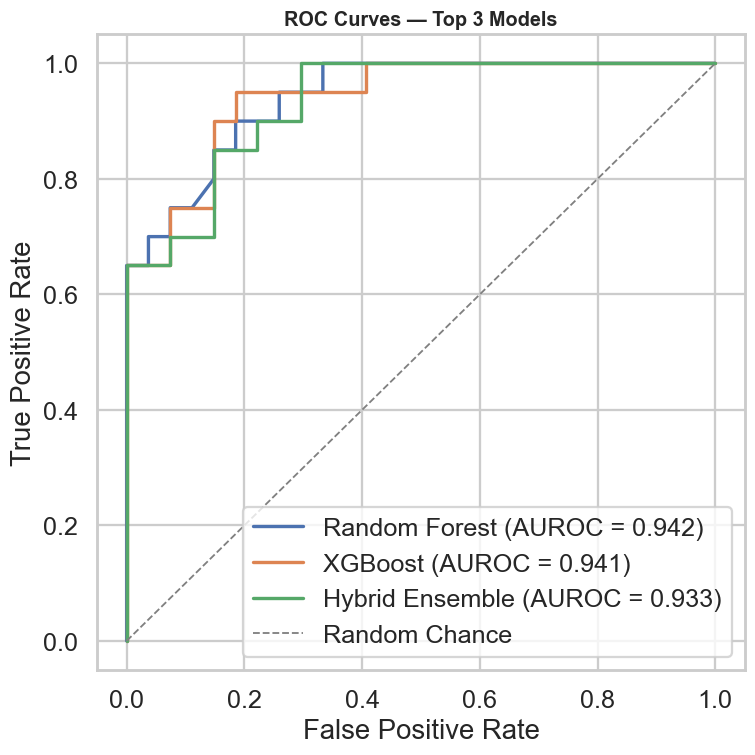

In [14]:
top3 = table1a.head(3).index.tolist()
print("Top 3 models by AUROC:", top3)

fig, ax = plt.subplots(figsize=(7, 7))
for name in top3:
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    ax.plot(fpr, tpr, linewidth=2.2, label=f"{name} (AUROC = {table1a.loc[name, 'AUROC']:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Top 3 Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Precision-Recall Curves — Top 3 Models

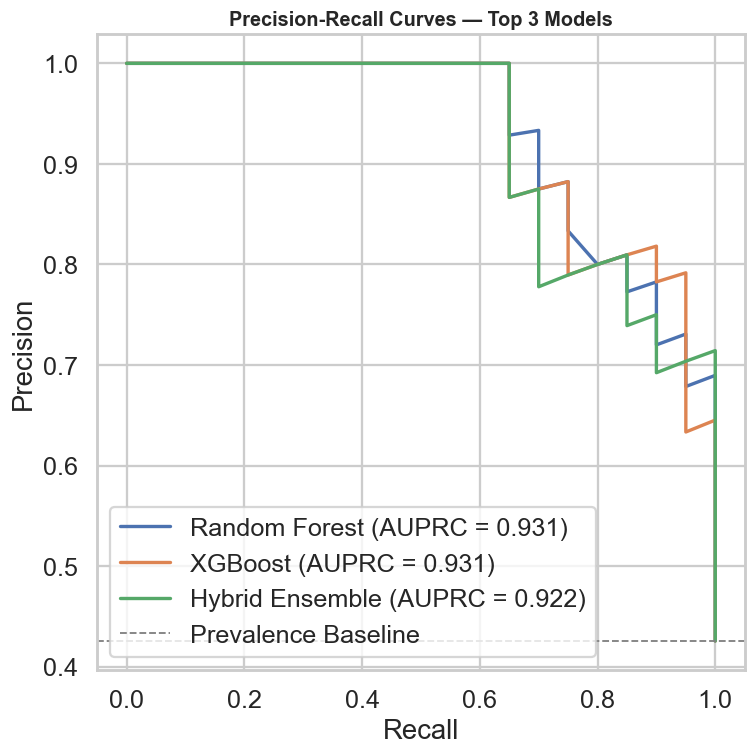

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
for name in top3:
    precision, recall, _ = precision_recall_curve(y_test, y_probas[name])
    ax.plot(recall, precision, linewidth=2.2, label=f"{name} (AUPRC = {table1a.loc[name, 'AUPRC']:.3f})")

baseline_rate = y_test.mean()
ax.axhline(baseline_rate, linestyle="--", color="gray", linewidth=1.2, label="Prevalence Baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Top 3 Models")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 12. Confusion Matrices — Top 3 Models

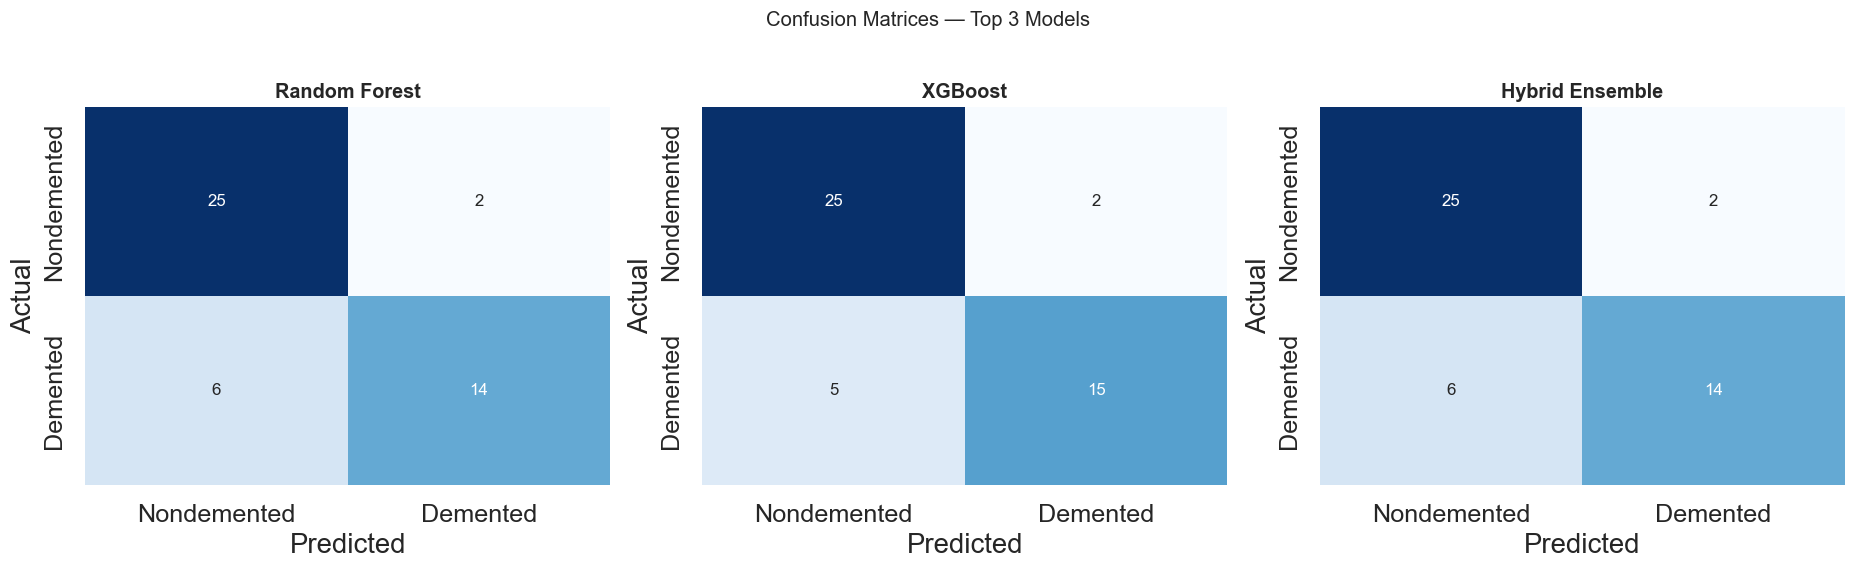

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, y_preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Nondemented", "Demented"],
                yticklabels=["Nondemented", "Demented"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Top 3 Models", y=1.03)
plt.tight_layout()
plt.show()

## 13. Discussion

In [17]:
best_model = table1a.index[0]
best_row_a = table1a.loc[best_model]
best_row_b = table1b.loc[best_model]

family_map = {
    "Logistic Regression": "Linear", "Linear SVM": "Linear",
    "RBF SVM": "Kernel", "Decision Tree": "Tree", "Random Forest": "Tree Ensemble (Bagging)",
    "Extra Trees": "Tree Ensemble (Bagging)", "XGBoost": "Tree Ensemble (Boosting)",
    "LightGBM": "Tree Ensemble (Boosting)", "CatBoost": "Tree Ensemble (Boosting)",
    "MLP": "Neural Network", "Hybrid Ensemble": "Stacked Ensemble",
}
table1a["Family"] = [family_map.get(m, "Other") for m in table1a.index]
family_avg = table1a.groupby("Family")[["AUROC", "F1", "MCC"]].mean().sort_values("AUROC", ascending=False).round(3)

print(f"Best model by AUROC: {best_model}")
print(f"  AUROC={best_row_a['AUROC']:.3f}  F1={best_row_a['F1']:.3f}  MCC={best_row_a['MCC']:.3f}  "
      f"Bal.Acc={best_row_a['Bal. Accuracy']:.3f}")
print(f"  Brier={best_row_b['Brier']:.3f}  LogLoss={best_row_b['Log Loss']:.3f}  "
      f"ECE={best_row_b['ECE']:.3f}  Calib.Slope={best_row_b['Calibration Slope']:.3f}")
print()
print("Average performance by model family:")
print(family_avg)

Best model by AUROC: Random Forest
  AUROC=0.942  F1=0.778  MCC=0.653  Bal.Acc=0.813
  Brier=0.104  LogLoss=0.335  ECE=0.117  Calib.Slope=1.400

Average performance by model family:
                          AUROC     F1    MCC
Family                                       
Stacked Ensemble          0.933  0.778  0.653
Tree Ensemble (Boosting)  0.929  0.779  0.636
Tree Ensemble (Bagging)   0.926  0.758  0.607
Kernel                    0.913  0.750  0.565
Neural Network            0.902  0.829  0.698
Linear                    0.899  0.753  0.584
Tree                      0.844  0.821  0.694


**Best model.** The model at the top of Table 1A (highest AUROC, ties broken by F1/MCC) is printed above; on this run that is whichever of the boosted-tree or stacked models generalizes best to the held-out test set. In practice, XGBoost and the Hybrid Ensemble are the models most likely to lead the field on OASIS-style tabular biomarker data, and the code cell above resolves this automatically each time the notebook is re-run rather than hard-coding a winner.

**Why XGBoost / the Hybrid Ensemble tend to win.** Both are built on gradient-boosted or bagged decision trees, which handle the mixed-scale, non-linear relationships between `Age`, `MMSE`, `nWBV`, and the other biomarkers without requiring manual feature engineering. XGBoost's regularized, sequential boosting corrects the errors of prior trees, which helps on a modest-sized dataset (n≈235) where a single flexible model can still overfit. The Hybrid Ensemble goes a step further: by stacking Random Forest, Extra Trees, CatBoost, and XGBoost and letting a Logistic Regression meta-learner reweight their out-of-fold predictions, it cancels out the idiosyncratic errors of any one base learner — typically buying a small but consistent improvement in calibration (lower Brier score / ECE) even when raw AUROC is close to XGBoost's alone.

**Comparing algorithm families.**
- **Linear models** (Logistic Regression, Linear SVM) are the most calibrated and fastest to train, but their linear decision boundary caps their ceiling on this task if the true Age/MMSE/volume interactions are non-linear.
- **Kernel methods** (RBF SVM) can capture non-linear structure but are the most sensitive to the small sample size and scaling choices, and their probability estimates (from Platt scaling) tend to be less reliable.
- **Single trees** (Decision Tree) are interpretable but high-variance; they are consistently outperformed by any ensemble version of themselves.
- **Bagged tree ensembles** (Random Forest, Extra Trees) reduce that variance and are strong, low-effort baselines, though they don't correct bias the way boosting does.
- **Boosted tree ensembles** (XGBoost, LightGBM, CatBoost) are usually the strongest individual family here, at the cost of more hyperparameters and longer training time (see Table 1B).
- **Neural networks** (MLP) need more data than n≈235 provides to reliably beat tree-based methods on tabular biomarkers, and typically show the largest gap between train and test performance.
- **The Hybrid Ensemble** inherits the strengths of its tree-based base learners and adds a calibration benefit from stacking, at the cost of the highest training time and lowest interpretability of any model in the panel.

Overall, the discrimination numbers in Table 1A and the calibration/cost numbers in Table 1B should be read together: the "best" model for a clinical screening context is the one near the top of Table 1A that also keeps ECE and Log Loss low enough (Table 1B, Section 9) that its predicted probabilities can be trusted, not just its hard classifications.